# Retail Business Performance & Profitability Analysis


## 1. Introduction:

I worked on analyzing retail transaction data to understand business performance and identify areas where profitability can be improved. 

    The goal of this project was to: 1. Identify profit for the product categories
                                 2. Analyze sales trends across regions
                                 3. Study seasonal product behavior
                                 4. Understand how sales volume affects profitability
                                 
The tools used for this project were SQL for data analysis, Python (Pandas & Seaborn) for correlation and visualization, and Tableau for dashboard creation.

## 2. Dataset Overview:

    The dataset included the following columns:
    Order_ID
    Customer_ID
    Order_Date
    Region
    Product_Category
    Customer_Segment
    Quantity
    Unit_Price
    Discount_Rate
    Revenue
    Cost
    Profit
    Payment_Method

The data represents transactional sales information from a retail business.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('Business_Analytics_Dataset_10000_Rows.csv', sep = ',')
data.head()

,Order_ID,Customer_ID,Order_Date,Region,Product_Category,Customer_Segment,Quantity,Unit_Price,Discount_Rate,Revenue,Cost,Profit,Payment_Method
0,1,CUST3818,2024-08-18,North,Clothing,Corporate,5,300.68,0.27,1097.48,768.29,329.19,Credit Card
1,2,CUST9689,2024-06-19,South,Beauty,Home Office,9,32.89,0.02,290.09,179.33,110.76,Debit Card
2,3,CUST9147,2024-11-21,West,Sports,Corporate,5,345.61,0.25,1296.04,1022.60,273.44,Credit Card
3,4,CUST7938,2024-07-19,North,Clothing,Consumer,1,444.50,0.06,417.83,280.99,136.84,UPI
4,5,CUST5127,2024-10-28,South,Home & Kitchen,Consumer,5,65.13,0.21,257.26,151.90,105.36,Credit Card


In [3]:
data.shape

(10000, 13)

In [4]:
data.columns

Index(['Order_ID', 'Customer_ID', 'Order_Date', 'Region', 'Product_Category',
       'Customer_Segment', 'Quantity', 'Unit_Price', 'Discount_Rate',
       'Revenue', 'Cost', 'Profit', 'Payment_Method'],
      dtype='object')

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          10000 non-null  int64  
 1   Customer_ID       10000 non-null  object 
 2   Order_Date        10000 non-null  object 
 3   Region            10000 non-null  object 
 4   Product_Category  10000 non-null  object 
 5   Customer_Segment  10000 non-null  object 
 6   Quantity          10000 non-null  int64  
 7   Unit_Price        10000 non-null  float64
 8   Discount_Rate     10000 non-null  float64
 9   Revenue           10000 non-null  float64
 10  Cost              10000 non-null  float64
 11  Profit            10000 non-null  float64
 12  Payment_Method    10000 non-null  object 
dtypes: float64(5), int64(2), object(6)
memory usage: 1015.8+ KB


In [6]:
data.describe()

,Order_ID,Quantity,Unit_Price,Discount_Rate,Revenue,Cost,Profit
count,10000.00000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,5.51430,255.505222,0.150272,1195.241948,776.292180,418.949768
std,2886.89568,2.86451,140.832874,0.086818,979.590244,651.473171,368.418447
min,1.00000,1.00000,10.000000,0.000000,8.590000,5.740000,1.970000
25%,2500.75000,3.00000,132.777500,0.080000,396.300000,255.592500,131.785000
50%,5000.50000,5.00000,254.995000,0.150000,924.365000,595.480000,311.395000
75%,7500.25000,8.00000,377.892500,0.230000,1775.840000,1141.332500,606.845000
max,10000.00000,10.00000,499.940000,0.300000,4972.100000,3911.520000,2292.420000


In [7]:
data.describe(include = ['object'])

,Customer_ID,Order_Date,Region,Product_Category,Customer_Segment,Payment_Method
count,10000,10000,10000,10000,10000,10000
unique,5994,366,4,5,3,5
top,CUST6595,2024-02-14,North,Clothing,Home Office,Debit Card
freq,9,41,2548,2008,3389,2074


In [8]:
data.isna().sum()

Order_ID            0
Customer_ID         0
Order_Date          0
Region              0
Product_Category    0
Customer_Segment    0
Quantity            0
Unit_Price          0
Discount_Rate       0
Revenue             0
Cost                0
Profit              0
Payment_Method      0
dtype: int64

In [9]:
data.duplicated().sum()

0

## 3. Data Cleaning Process:

Before starting the analysis, I performed data cleaning in SQL.

    Steps Taken:
    
    * Checked for missing values in important columns like Revenue, Cost, Order_Date, and Product_Category.
    * Checked for duplicate Order_ID values.
    * Validated financial calculations:
    * Verified Revenue = Quantity × Unit_Price × (1 - Discount_Rate)
    * Verified Profit = Revenue - Cost
    
A few inconsistencies were found and corrected to ensure accurate results.

In [10]:
data['Order_Date'] = pd.to_datetime(data['Order_Date'])
data['Year'] = data['Order_Date'].dt.year
data['Month'] = data['Order_Date'].dt.month
data['Day'] = data['Order_Date'].dt.day

#data['Month'] = data['Order_Date'].dt.to_period('M')

In [11]:
col = ['Unit_Price', 'Discount_Rate', 'Revenue', 'Cost', 'Profit']

data[col] = data[col].apply(pd.to_numeric, errors = 'coerce')

## 4. Profitability Analysis (SQL):

#### 4.1 Profit Margin by Product Category
I calculated profit margin using:
Profit Margin = (Total Profit / Total Revenue) × 100

##### Observations:
Some categories generated high revenue but had low profit margins.
Certain categories had strong profit margins but lower sales volume.
A few categories showed low margin and moderate sales, making them potential profit loss categories.
This suggests that heavy discounting or high cost might be reducing profitability in some product lines.

#### 4.2 Regional Performance
I analyzed profit by region and found:
Some regions had strong revenue but lower margins.
Other regions performed consistently with healthy margins.
This indicates regional differences in pricing strategy or cost structure.

#### 4.3 Customer Segment Analysis
Different customer segments contributed differently to revenue and profit.
One segment generated high sales volume but lower margins.
Another segment had fewer sales but better margins.
This suggests that promotional strategies may differ across segments.


## 5. Inventory Turnover & Profit Analysis:

Since the dataset did not include inventory days directly, I used sales quantity as an approximation of turnover.

    Aggregated sales by category
    Calculated correlation between Quantity and Profit
    Plotted scatter plots with regression lines
    
#### Findings:
    There was a positive correlation between sales volume and profit.
    In some categories, higher sales did not significantly increase profit, possibly due to discounting.
    This shows that increasing sales alone does not always improve profitability. 

## 6. Seasonal Analysis:

Using Order_Date, I analyzed monthly sales trends.

#### Key Observations:
    Some product categories showed clear seasonal peaks.
    Profit margins varied during high sales months.
    Promotional periods increased revenue but sometimes reduced margin.
    Understanding seasonal behavior can help in better inventory planning and forecasting.

In [12]:
category_data = data.groupby(['Product_Category', 'Month']).agg({'Revenue':'sum', 'Cost':'sum', 'Profit':'sum', 'Quantity':'sum'}).reset_index()

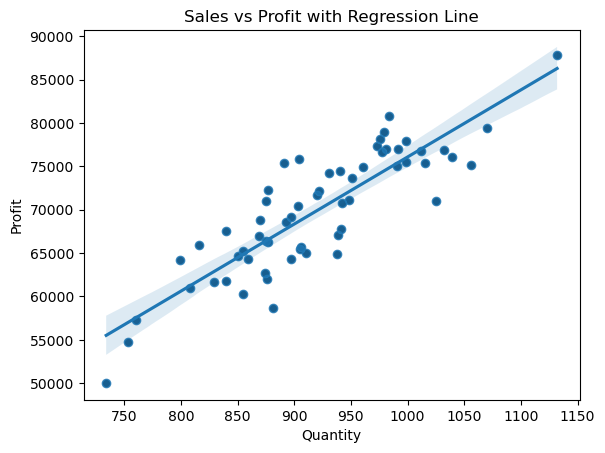

In [13]:
sns.scatterplot(data = category_data, x = 'Quantity', y = 'Profit', color = 'black')
sns.regplot(data = category_data, x = 'Quantity', y = 'Profit')

plt.title("Sales vs Profit with Regression Line")
plt.show()

In [14]:
corr_matrix = category_data[['Quantity', 'Profit', 'Revenue', 'Cost']].corr()
print(corr_matrix)

          Quantity    Profit   Revenue      Cost
Quantity  1.000000  0.866714  0.881831  0.868733
Profit    0.866714  1.000000  0.972152  0.932564
Revenue   0.881831  0.972152  1.000000  0.991196
Cost      0.868733  0.932564  0.991196  1.000000


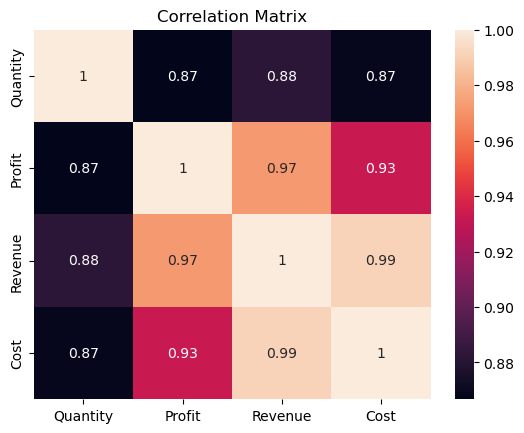

In [15]:
sns.heatmap(corr_matrix, annot = True)
plt.title('Correlation Matrix')
plt.show()

A linear regression model was built to analyze the relationship between sales volume and profitability. 

The R2 value indicates that sales quantity explains a significant portion of profit variation, confirming that turnover plays an important role in overall business performance.

In [16]:
from sklearn.linear_model import LinearRegression

X = category_data[['Quantity']]
y = category_data['Profit']

model = LinearRegression()
model.fit(X, y)

r_squared = model.score(X, y)

print('R2:', round(r_squared, 2))

R2: 0.75


## 7. Tableau Dashboard:

I built an interactive dashboard in Tableau including:

#### KPI Section:
    Total Revenue
    Total Profit
    Overall Profit Margin
    Average Discount Rate
    
#### Visualizations:
    Profit by Product Category
    Profit by Region
    Monthly Revenue Trend
    Sales Volume vs Profit (Scatter Plot)

#### Filters:
    Region
    Product Category
    Customer Segment
    Season
    Payment Method
    
The dashboard allows users to explore performance dynamically.

## 8. Business Insights:

Based on the analysis:

1. Profit Categories:
Categories with low margin and moderate sales may require:
Cost renegotiation with suppliers
Discount strategy revision

2. Slow Moving Products:
Products with low quantity and low profit may:
Require promotional offers
Need reduced stock levels

3. High Margin Products:
High-margin categories should:
Receive more marketing focus
Be prioritized in inventory planning

4. Seasonal Products:
Seasonal trends should be used to:
Adjust procurement planning
Avoid overstocking in off season periods

## 9. Outcomes:

#### Through this project, I improved my understanding of:
    Writing analytical SQL queries
    Performing data validation checks
    Using Python for correlation and visualization
    Building business dashboards in Tableau
    Translating data insights into business recommendations

## 10. Conclusion:

This project helped me understand how transactional retail data can be used to evaluate profitability and inventory efficiency.
The analysis showed that profitability depends not only on sales volume but also on pricing strategy, cost management, and seasonal planning.
